## Bayesian Optimization -- Manual Implementation

In [117]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### BO Utils Class

In [118]:
class bayesian_optimization_util():
    @staticmethod
    def plot_approximation(gpr, X, Y, X_sample, Y_sample, X_next=None, show_legend=False):
        mu, std = gpr.predict(X, return_std=True)
        plt.fill_between(X.ravel(), 
                         mu.ravel() + 1.96 * std, 
                         mu.ravel() - 1.96 * std, 
                         alpha=0.1) 
        plt.plot(X, Y, 'y--', lw=1, label='Noise-free objective')
        plt.plot(X, mu, 'b-', lw=1, label='Surrogate function')
        plt.plot(X_sample, Y_sample, 'kx', mew=3, label='Noisy samples')
        if X_next:
            plt.axvline(x=X_next, ls='--', c='k', lw=1)
        if show_legend:
            plt.legend()

    @staticmethod
    def plot_acquisition(X, Y, X_next, show_legend=False):
        plt.plot(X, Y, 'r-', lw=1, label='Acquisition function')
        plt.axvline(x=X_next, ls='--', c='k', lw=1, label='Next sampling location')
        if show_legend:
            plt.legend()    

    @staticmethod
    def plot_convergence(X_sample, Y_sample, n_init=2):
        plt.figure(figsize=(12, 3))
    
        x = X_sample[n_init:].ravel()
        y = Y_sample[n_init:].ravel()
        r = range(1, len(x)+1)
        
        x_neighbor_dist = [np.abs(a-b) for a, b in zip(x, x[1:])]
        y_max_watermark = np.maximum.accumulate(y)
        
        plt.subplot(1, 2, 1)
        plt.plot(r[1:], x_neighbor_dist, 'bo-')
        plt.xlabel('Iteration')
        plt.ylabel('Distance')
        plt.title('Distance between consecutive x\'s')
    
        plt.subplot(1, 2, 2)
        plt.plot(r, y_max_watermark, 'ro-')
        plt.xlabel('Iteration')
        plt.ylabel('Best Y')
        plt.title('Value of best selected sample')

In [33]:
bo_util = bayesian_optimization_util()

### Underlying Function

Here the explicit form of the underlying function form is given. For the demonstration purpose,
it is used to simulate the data sampling. Meanwhile, it will be the function that we are trying
to maximize. In practice, we usually do not have such an anylytical form for the function we
want to optimize. But the idea demonstrated here applies generally -- the object we want to
optimize is a function which in general sense takes in some input (for general problems that
the Bayesian optimization to solve, it is usually high dimensional) and yields some output.
Such an input-output mapping can be something computational, like the practical example shown
in the `Bayesian Optimization for Hyperparameter Optimization` section below, where the function
we try to optimize is mapping the hyperparameters to network performance. Or, the mapping can be
for some physical measurement, e.g., the composition of high entropy alloys mapping to the
hardness of the HEAs.

In [145]:
bounds = np.array([[-1.0, 2.0]])
noise = 0.2

def f(X, noise=noise):
    return -np.sin(3 * X) - X**2 + 0.7 * X + noise * np.random.randn(*X.shape)

# Here the outmost layer of the list contains the samples and the internal layer
# is the actual sampling point. The reason why we need a list for a single number
# is `[-0.9]` refers to the coordinate in the configuration space. In the demo
# case here, we only have one dimension but in practice, it can be higher.
X_init = np.array([[-0.9], [1.1]])
Y_init = f(X_init)

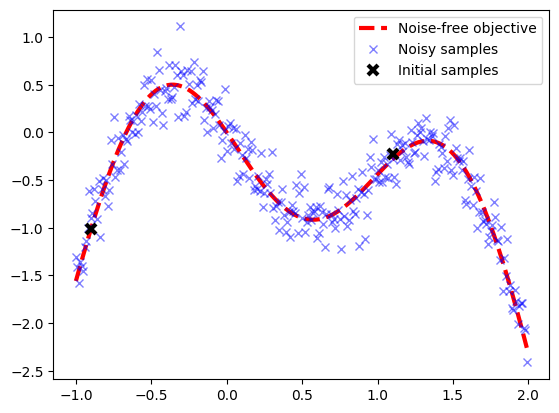

In [146]:
X = np.arange(bounds[:, 0], bounds[:, 1], 0.01).reshape(-1, 1)

# Noise-free objective function values at X with noise = 0
Y = f(X, 0)

# Plot optimization objective with noise level
plt.plot(X, Y, 'r--', lw=3, label='Noise-free objective')
plt.plot(X, f(X), 'bx', lw=1, alpha=0.5, label='Noisy samples')
plt.plot(X_init, Y_init, 'kx', mew=3, markersize=7, label='Initial samples')
plt.legend();

Here I put all the three types of acquisition function into the same function.

- The default option is the natural default -- `ei` for `Expected Improvement`
- The implementation here is for maximization problem.
- For minimization problem, we only need to reverse the sign for `imp` for `pi` and `ei`, or reverse the sign in front of the `kappa` term for `ucb` (the name may need to change to `lcb`).

In [150]:
import numpy as np
from scipy.stats import norm

def acquisition_func(X, X_sample, Y_sample, gpr, kind='ei', xi=0.01, kappa=2.576):
    '''Acquisition function values at X for a GP surrogate.

    Args:
        X: Points at which the acquisition is computed (m x d).
        X_sample: Sample locations (n x d).
        Y_sample: Sample values (n x 1).
        gpr: A GaussianProcessRegressor fitted to samples.
        kind: 'ei', 'pi', or 'ucb'.
        xi: Exploration margin for EI/PI.
        kappa: Exploration weight for UCB.
    Returns:
        Acquisition values at X (m x 1). Maximize in all three cases.
    '''
    mu, sigma = gpr.predict(X, return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)

    if kind == 'ucb':
        return mu + kappa * sigma

    mu_sample_opt = np.max(gpr.predict(X_sample))
    imp = mu - mu_sample_opt - xi

    with np.errstate(divide='ignore', invalid='ignore'):
        Z = imp / sigma
        if kind == 'ei':
            acq = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        elif kind == 'pi':
            acq = norm.cdf(Z)
        else:
            raise ValueError(f"unknown acquisition function: {kind!r}")

    acq[sigma == 0.0] = 0.0

    return acq

With Bayesian optimization, we establish a way to find the extrema of an unknown function and finally this will be turned into finding the extrema of a known function (i.e., the acquisition function). One thing we should not forget is finding the extrema of a known function especially when the input is high dimensional, is not a trivial task. But at least it is a standard optimization problem for which we have some existing algorithms to help us, e.g., the `L-BFGS-B` method used below for minimizing the acqusition function.

In [159]:
from scipy.optimize import minimize

def propose_location(acquisition, X_sample, Y_sample, gpr, bounds, n_restarts=25, kind='ei'):
    '''Proposes the next sampling point by optimizing the acquisition function.

    Args:
        acquisition: Acquisition function.
        X_sample: Sample locations (n x d).
        Y_sample: Sample values (n x 1).
        gpr: A GaussianProcessRegressor fitted to samples.

    Returns:
        Location of the acquisition function maximum.
    '''
    dim = X_sample.shape[1]
    min_val = 1
    min_x = None

    def min_obj(X):
        # Minimization objective is the negative acquisition function since we are dealing with
        # the maximization problem here for the demo.
        return -acquisition(X.reshape(-1, dim), X_sample, Y_sample, gpr, kind=kind)

    # Find the best optimum by starting from n_restart different random points.
    for x0 in np.random.uniform(bounds[:, 0], bounds[:, 1], size=(n_restarts, dim)):
        res = minimize(min_obj, x0=x0, bounds=bounds, method='L-BFGS-B')
        if res.fun < min_val:
            min_val = res.fun
            min_x = res.x           

    return min_x.reshape(-1, 1)

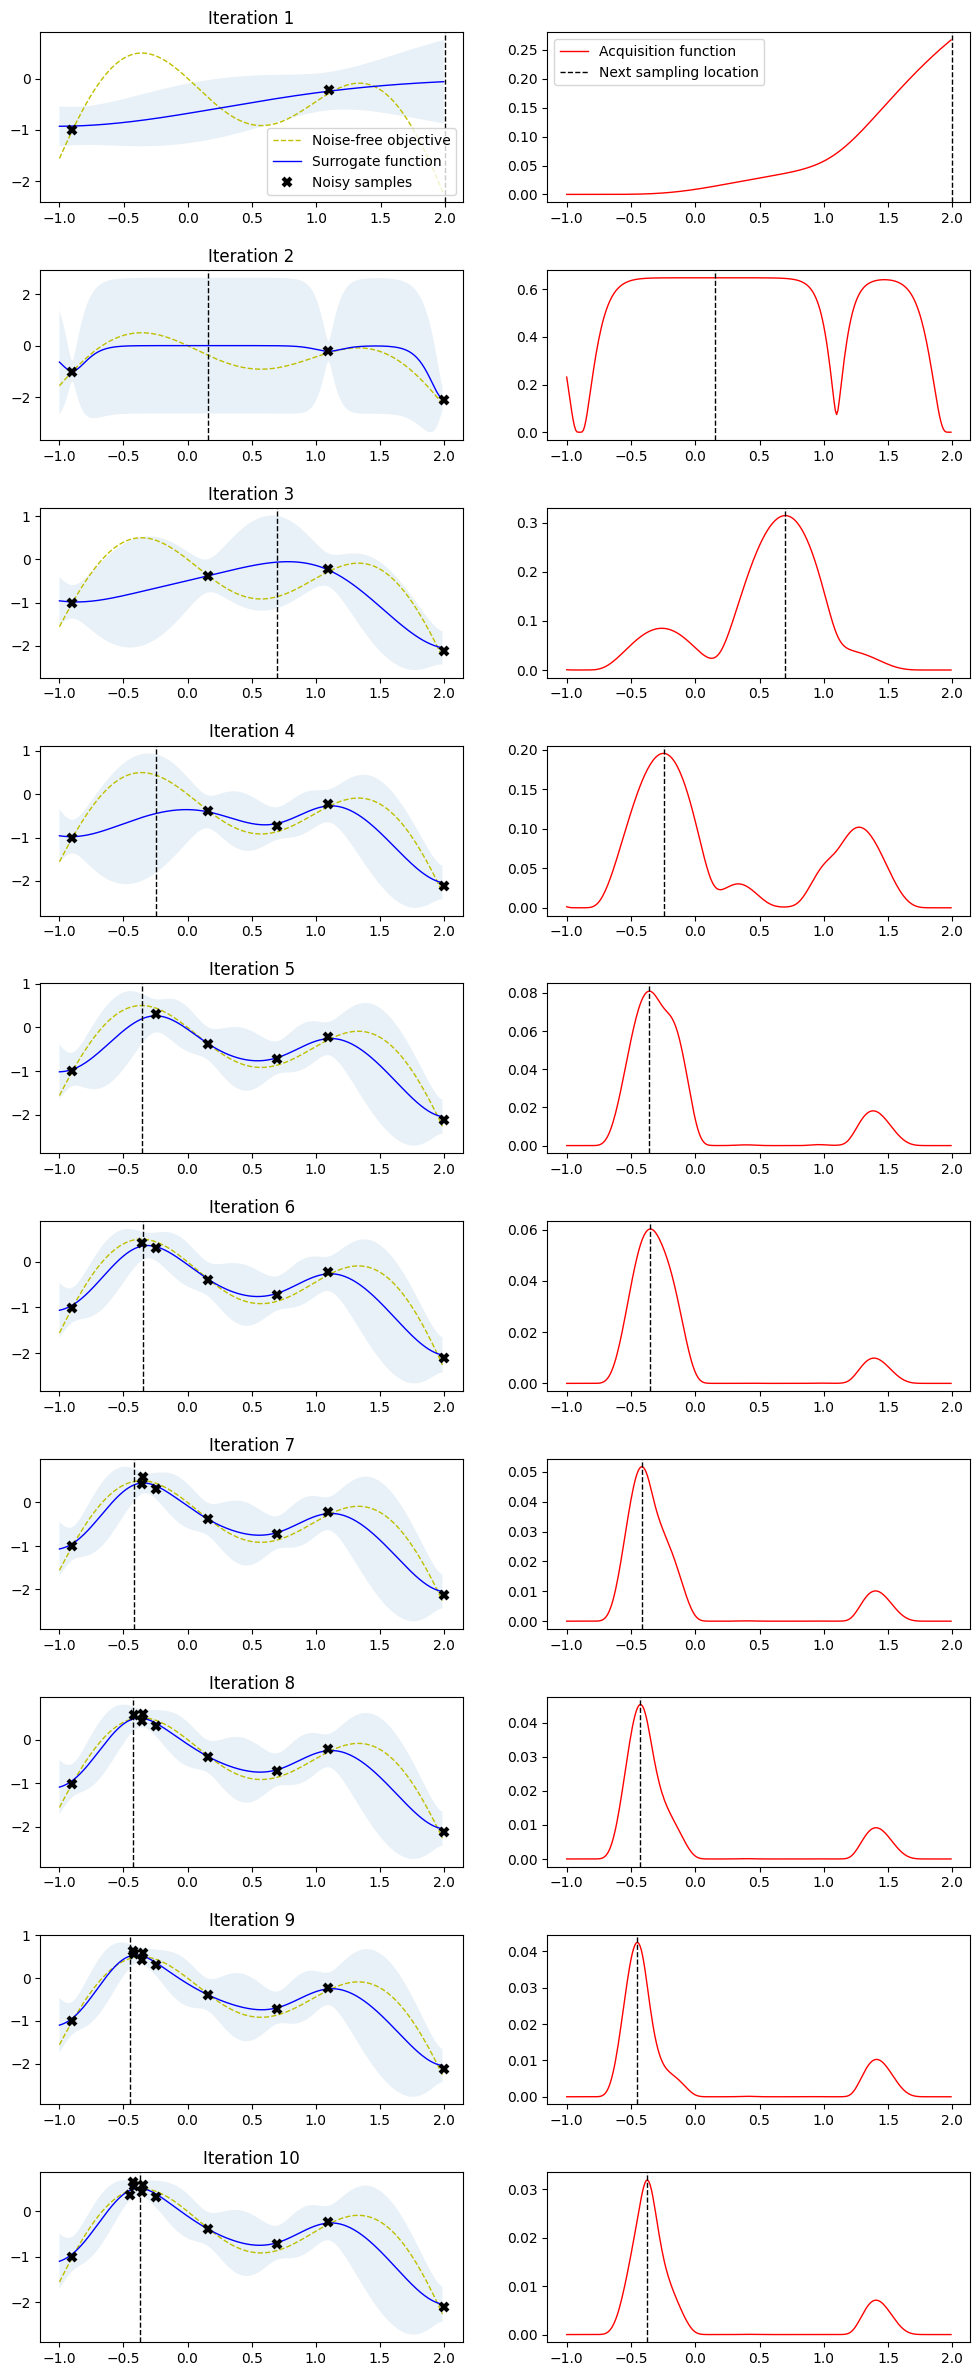

In [158]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern

# Gaussian process with the Materrn kernel
m52 = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
gpr = GaussianProcessRegressor(kernel=m52, alpha=noise**2)

X_sample = X_init
Y_sample = Y_init

n_iter = 10

plt.figure(figsize=(12, n_iter * 3))
plt.subplots_adjust(hspace=0.4)

for i in range(n_iter):
    gpr.fit(X_sample, Y_sample)

    X_next = propose_location(acquisition_func, X_sample, Y_sample, gpr, bounds)
    Y_next = f(X_next, noise)

    plt.subplot(n_iter, 2, 2 * i + 1)
    bo_util.plot_approximation(gpr, X, Y, X_sample, Y_sample, X_next, show_legend=i==0)
    plt.title(f'Iteration {i+1}')

    plt.subplot(n_iter, 2, 2 * i + 2)
    bo_util.plot_acquisition(X, expected_improvement(X, X_sample, Y_sample, gpr), X_next, show_legend=i==0)

    X_sample = np.vstack((X_sample, X_next))
    Y_sample = np.vstack((Y_sample, Y_next))

## Bayesian Optimization for Hyperparameter Optimization

Now we are trying to deal with the optimization problem for a practical function. The problem here
is a very representative one for those general problems -- optimizing the mapping from high
dimensional configuration space to some value, where we don't even have an analytical form.
Specifically for the example here, it is a mapping from the combination of hyperparameters to the
performance of the prediction framework. This is a typical problem where the Bayesian optimization
could be helpful. The `prediction framework` specifically refers to the `XGBRegressor` which builds
on top of decision trees to perform the regression against the training data. It comes with various
hyperparameters which controls how well the regressor is performing. The Bayesian optimization is
useful here for tuning those hyperparameters in a more efficient way, targeting at optimal performance
of the regression.

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

The Bayesian optimization module used here was provided by the `GPyOpt` package which is no longer
maintained.

An alternative is [https://github.com/bayesian-optimization/bayesianoptimization](https://github.com/bayesian-optimization/bayesianoptimization).

+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

In [131]:
from sklearn import datasets
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

from scipy.stats import uniform
from xgboost import XGBRegressor

X, Y = datasets.load_diabetes(return_X_y=True)
xgb = XGBRegressor()

The first trial for hyperparameters optimization is using a brutal force random search. Basically,
it wonders around the hyperparameter space and see what combination of hyperparameters is giving
us the optimal performance of the regressor (`xgb = XGBRegressor()`).

In [132]:
param_dist = {
    "learning_rate": uniform(0, 1),
    "gamma": uniform(0, 5),
    "max_depth": range(1,50),
    "n_estimators": range(1,300),
    "min_child_weight": range(1,10)
}

rs = RandomizedSearchCV(
    xgb, param_distributions=param_dist, 
    scoring='neg_mean_squared_error', n_iter=25
)

rs.fit(X, Y);

Now, we target at the same thing -- finding the optimal hyperparameters to yield the best performance of the regressor. The Bayesian optimization is a typical method for dealing with such problems to explore the high dimensional configuration space (in this case, the hyperparameter hyper-space) efficiently.

As mentioned earlier, for the Bayesian optimization to work, we need a target function that we want to optimize. We already see how it works with the analytical function from  the very first example on the top, by implementing everything explicitly. Here for the example of hyperparameter optimization, we no longer have an analytical function but still we can define a function that maps input parameters to an output. The input here is just the hyperparameter for the regressor and the output is the corresponding score (which basically measures how well the regressor performs in prediction). The `scoring='neg_mean_squared_error'` below defines the way of calculating the score. The `cv_score` function is just the black-box function that we want to optimize, with respect to the input `parameters`. The input hyperparameters to optimize against are defined in the `domain` variable `bds` which comes in the form of the Python dict. The `BayesianOptimization` is responsible for turning the dict into a list form and passing to the `cv_score` function for the score evaluation.

Again, we need to pay attention to the shape of the `parameters` parameter. It is a two-dimensional array -- the outmost layer contains the samples and each of the samples corresponds to a certain coordinate in the high dimensional hyperparameter space. The inside layer just contains the hyperparameter coordinate and here each coordinate contains 5 components, corresponding to each of the hyperparameters to be tuned.

In [133]:
from GPyOpt.methods import BayesianOptimization

bds = [
    {'name': 'learning_rate', 'type': 'continuous', 'domain': (0, 1)},
    {'name': 'gamma', 'type': 'continuous', 'domain': (0, 5)},
    {'name': 'max_depth', 'type': 'discrete', 'domain': (1, 50)},
    {'name': 'n_estimators', 'type': 'discrete', 'domain': (1, 300)},
    {'name': 'min_child_weight', 'type': 'discrete', 'domain': (1, 10)}
]

def cv_score(parameters):
    parameters = parameters[0]
    score = cross_val_score(
        XGBRegressor(
            learning_rate=parameters[0],
            gamma=int(parameters[1]),
            max_depth=int(parameters[2]),
            n_estimators=int(parameters[3]),
            min_child_weight = parameters[4]
        ), 
        X, Y,
        scoring='neg_mean_squared_error'
    ).mean()
    score = np.array(score)
    return score

optimizer = BayesianOptimization(
    f=cv_score,
    domain=bds,
    model_type='GP',
    acquisition_type ='EI',
    acquisition_jitter = 0.05,
    exact_feval=True, 
    maximize=True
)

optimizer.run_optimization(max_iter=20)

Random search neg. MSE = -3553.23
Bayesian optimization neg. MSE = -3191.26


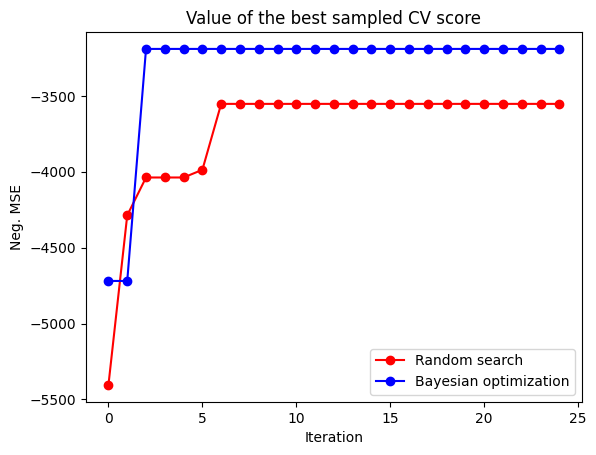

In [135]:
y_rs = np.maximum.accumulate(rs.cv_results_['mean_test_score'])
y_bo = np.maximum.accumulate(-optimizer.Y).ravel()

print(f'Random search neg. MSE = {y_rs[-1]:.2f}')
print(f'Bayesian optimization neg. MSE = {y_bo[-1]:.2f}')

plt.plot(y_rs, 'ro-', label='Random search')
plt.plot(y_bo, 'bo-', label='Bayesian optimization')
plt.xlabel('Iteration')
plt.ylabel('Neg. MSE')
plt.title('Value of the best sampled CV score');
plt.legend();

## Bayesian Optimization for Hyperparameter Optimization -- Another Example

In [164]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('mpg').dropna()

X = df.drop(columns=['mpg'])
y = df['mpg']

In [165]:
X = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [138]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 2.967
R²: 0.834


The `GridSearchCV` routine used here below provides another approach for the hyperparameter optimization. We provide candidate values for each of the hyperparameters and put together, they will form the meshgrid for the regressor to explore over. The exploration will then be performed in a point-by-point manner without guidance.

In [161]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid,
    cv=3, n_jobs=1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'subsample': 0.8}


In [162]:
y_pred = grid_search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 2.804
R²: 0.851


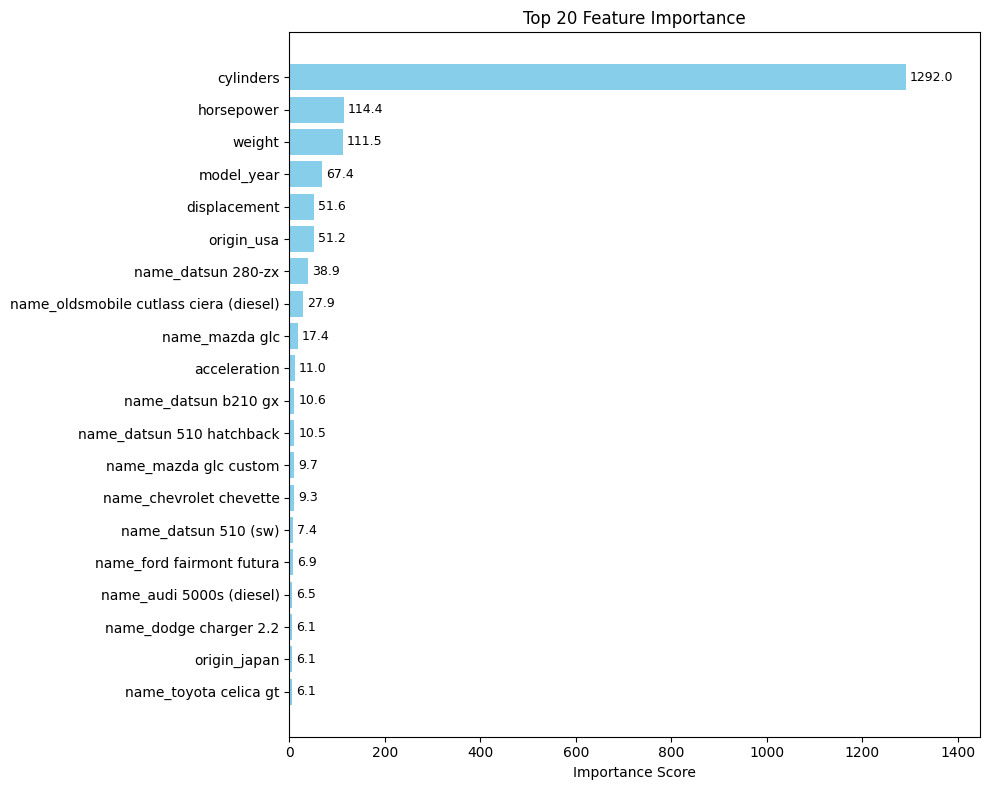

In [166]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

best_model = grid_search.best_estimator_
importance = best_model.get_booster().get_score(importance_type='gain')

s = (
    pd.Series(importance).reindex(X.columns, fill_value=0).sort_values(ascending=False)
)

top_n = 20
s = s.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(s.index, s.values, color='skyblue')

ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.margins(x=0.12)

ax.set_xlabel('Importance Score')
ax.set_title(f'Top {top_n} Feature Importance')
fig.tight_layout()
plt.show()

The `BayesSearchCV` module provided by `scikit-optimize` is one of the alternatives Bayesian optimization modules.

- See the documentation [here](https://scikit-optimize.github.io/stable/modules/generated/skopt.BayesSearchCV.html)
- Another alternative can be found [here](https://github.com/bayesian-optimization/bayesianoptimization)

In [142]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

hyper_params = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
     'subsample': Real(0.5, 1.0),
     'colsample_bytree': Real(0.5, 1.0),
     'max_depth': Integer(2, 10),
     'n_estimators': Integer(50, 500)
}

search = BayesSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    hyper_params,
    n_iter=40, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)

Best parameters: OrderedDict({'colsample_bytree': 1.0, 'learning_rate': 0.0512868705069948, 'max_depth': 2, 'n_estimators': 449, 'subsample': 0.5})


In [143]:
y_pred = search.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

RMSE: 2.757
R²: 0.856


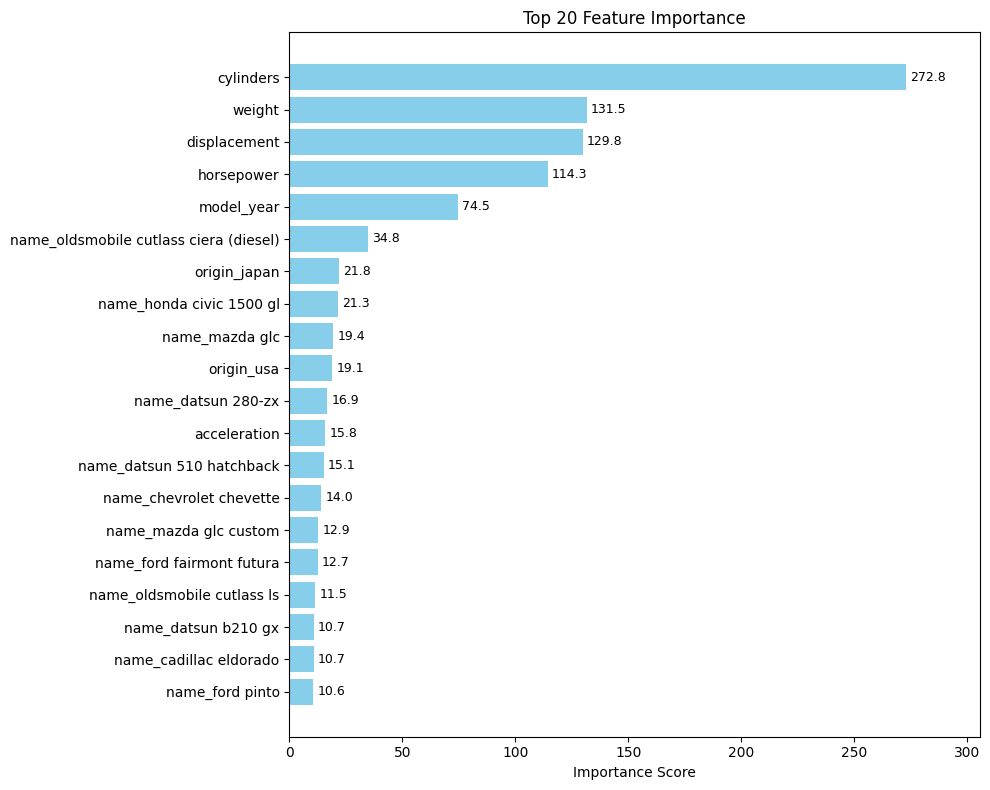

In [144]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

best_model = search.best_estimator_
importance = best_model.get_booster().get_score(importance_type='gain')

s = (pd.Series(importance)
       .reindex(X.columns, fill_value=0)
       .sort_values(ascending=False))

top_n = 20
s = s.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(s.index, s.values, color='skyblue')

ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax.margins(x=0.12)

ax.set_xlabel('Importance Score')
ax.set_title(f'Top {top_n} Feature Importance')
fig.tight_layout()
plt.show()